# Capstone Project: Google Data Analytics Course
### Role: Junior Data Analyst, on the marketing analyst team at Bellabeat.

# Introduction
Bellabeat is a high-tech manufacturer of health-focused products for women. Bellabeat is a successful small company, but they have the potential to become a larger player in the global smart device market. Urška Sršen, cofounder and Chief Creative Officer of Bellabeat, believes that
analyzing smart device fitness data could help unlock new growth opportunities for the company. You have been asked to focus on one of Bellabeat’s products and analyze smart device data to gain insight into how consumers are using their smart devices. The insights discovered will then help guide marketing strategy for the company. The analysis will be presented to the Bellabeat executive team along with high-level recommendations for Bellabeat’s marketing strategy.

# Ask
A report with the following deliverables, will be shared with the executive team:<br/>
1. A clear summary of the business task <br/>
2. A description of all data sources used <br/>
3. Documentation of any cleaning or manipulation of data<br/>
4. A summary of your analysis<br/>
5. Supporting visualizations and key findings<br/>
6. Your top high-level content recommendations based on your analysis<br/><br/>


**Business Task**<br/>
Analyse smart device data to gain insight into how consumers are using their smart devices, then focus on one of Bellabeats products to identify potential growth opportunities for the business. 


# Prepare
Public dataset used:
FitBit Fitness Tracker Data (CC0: Public Domain, data set made available through Mobius).<br/>
This Kaggle data set contains personal fitness tracker data from thirty fitbit users. Thirty eligible Fitbit users consented to the submission of personal tracker data, including minute-level output for physical activity, heart rate, and sleep monitoring.<br/><br/>


Data limitations include:<br/> 
**Reliability** - There are only 30 users meaning this data is not a large sample and may not be representative of the data population. Furthermore, there is no demographic data available about these users, meaning we are unable to confirm any influence of bias or external factors which would influence the outcome of this data analysis.<br/> 
**Original** - This is second party data, collected via survey.<br/>
**Comprehensive** - Some of the data in the files is missing and include duplicates, which have been identified throughout the cleaning process.<br/>
**Current** - This data is from 2016, meaning it is not current and outcomes of the analysis may not be representative of the current time. <br/>
**Cited** -  This data source is publicly available on Kaggle and is cited in many projects, namely for the use of the Google Data Analytics Course.<br/>

There are 27 files included in this dataset. For the purpose of this project, the following six files were used, from the date 3 March 2016 - 11 April 2016:<br/>
weight_log_info.csv<br/>
hourly_steps_merged.csv<br/>
hourly_calories_merged.csv<br/>
heartrate_seconds_merged.csv<br/>
minutes_sleep_merged.csv<br/>
daily_activity_merged.csv<br/>

# Process
The tools I have used for this project include Google Sheets, BigQuery (SQL) and Tableau. <br/>

Google Sheets was used for initial exploration of the data,including identifying SUM, MAX, MIN data, before uploading the files to BigQuery.<br/>

_*Note, when uploading the files to BigQuery, the date format in each file did not match the required format for Big Query, resulting in an error. To overcome this, I manually added the column names to the schema in string format, for each dataset to complete the uploads. During the cleaning process, I used the PARSED DATE function to change the dates from 'string' to 'timestamp'._<br/>

SQL was used to identify distinct users to see how many users' data was included in each spreadsheet. <br/>

| Table | Distinct Users |
| -------- | -------- |
| weight_log_info | 11 |
| hourly_steps | 34 |
| hourly_calories | 1 |
| heartrate_seconds | 14 |
| minutes_sleep | 24 |
| daily_activity | 35 |


Following this, the decision was made to exclude the hourly calories dataset from the analysis, due to data from only one user provided. <br/>

Duplicate data was identified in the sleep_merged (525 rows) table which were removed. 

Then, I was able to check columns in all tables included a new date/time column, changed to the correct data type of 'timestamp'.

In [1]:
query = """

SELECT
  CONCAT(table_catalog,".",table_schema,".",table_name) AS table_path,
  table_name,
  column_name
FROM
  `white-berm-496207-v8.fitbit_data.INFORMATION_SCHEMA.COLUMNS`
WHERE
  data_type IN ("TIMESTAMP", "DATETIME", "DATE");
"""

# Analyse and Share

### Sleep Analysis

Considering sleep related products as a possibility, analysis was conducted to see if or how people nap during the day. The assumption was made that a nap is any time someone goes to sleep and wakes up on the same day.

In [2]:
query = """

--Create temporary temple for sleep summary 

WITH
  sleep_summary AS (
    SELECT
      Id,
      log_d,
      
--Identify sleep start and end times

      MIN(DATE(parsed_date)) AS sleep_start,
      MAX(DATE(parsed_date)) AS sleep_end,
      
--Calculate duration of sleep sessions in hours, minutes and seconds

      TIME(
        TIMESTAMP_DIFF(MAX(parsed_date), MIN(parsed_date), HOUR),
        MOD(TIMESTAMP_DIFF(MAX(parsed_date), MIN(parsed_date), MINUTE), 60),
        MOD(
          MOD(TIMESTAMP_DIFF(MAX(parsed_date), MIN(parsed_date), SECOND), 3600),
          60))
        AS time_sleeping
    FROM `white-berm-496207-v8.fitbit_data.minutes_sleep_merged`
    WHERE value_numeric = 1
    
--Grouping sleep sessions by columns for id and logged sleep session    

    GROUP BY 1, 2

--Creating second temp table for daily sleep

  ),
  daily_sleep AS (
    SELECT
      Id,
      sleep_start AS sleep_date,

--Counting number of sleep sessions (naps) each day

      COUNT(log_d) AS number_naps,
      
--Summing sleep hours and extracting the hour from the time

      SUM(EXTRACT(HOUR FROM time_sleeping)) AS total_time_sleeping
    FROM sleep_summary

--Filtering same day sleep

    WHERE sleep_start = sleep_end
    
--Grouping by id and sleep date

    GROUP BY 1, 2
  )

--Final column selection

SELECT
  S.Id,
  S.sleep_date,
  A.total_steps,
  A.total_distance,
  S.number_naps,
  S.total_time_sleeping
FROM daily_sleep S

--Join and joining conditions

LEFT JOIN `white-berm-496207-v8.fitbit_data.daily_activity_merged` A
  ON S.Id = A.id AND S.sleep_date = A.parsed_activity_date
ORDER BY total_steps DESC;

"""

|Average total of hours sleep|	Highest number of naps|	Highest number of hours sleep|	Lowest number of hours sleep|
|----------------------------|------------------------|------------------------------|------------------------------|
|7.29|3|14|1|

Results show that consumers generally have healthy sleep duration, falling in the recommended adult sleep levels (7–9 hours), but there are highly inconsistent sleep patterns, suggesting opportunities for Bellabeat to focus on sleep quality and consistency, not just duration.
After calculating how many hours of sleep and naps are recorded, this data was used to analyse the impact of number of hours sleep on heart rate.

In [3]:
query = """

--Create temp table for daily sleep

WITH
  daily_sleep AS (
    SELECT
      Id,
      
--Extract date from timestamp

      DATE(parsed_date) AS sleep_date,

--Calculating total sleep hours. Value of 1 = awake, value of 0 = asleep. Totalling the values and converting minutes to hours.

      SUM(CASE WHEN value_numeric = 1 THEN 1 ELSE 0 END) / 60.0
        AS total_hours_sleep
    FROM `white-berm-496207-v8.fitbit_data.minutes_sleep_merged`

--Group by id and sleep date

    GROUP BY 1, 2

--Create temp table for daily heartrate

  ),
  daily_heartrate AS (
    SELECT
      id,

--Extracting date from timestamp

      DATE(parsed_time) AS activity_date,

--Calculating average heartrate

      AVG(SAFE_CAST(value AS FLOAT64)) AS avg_heartrate
    FROM `white-berm-496207-v8.fitbit_data.heartrate_seconds_merged`

--Group by id and activity date

    GROUP BY 1, 2
  )

--Final column select

SELECT 
    S.Id, 
    S.sleep_date, 
    S.total_hours_sleep, 
    H.avg_heartrate

--Join and joining conditions

FROM 
    daily_sleep S
INNER JOIN 
    daily_heartrate H
  ON S.Id = H.id AND S.sleep_date = H.activity_date
ORDER BY S.total_hours_sleep DESC;

"""

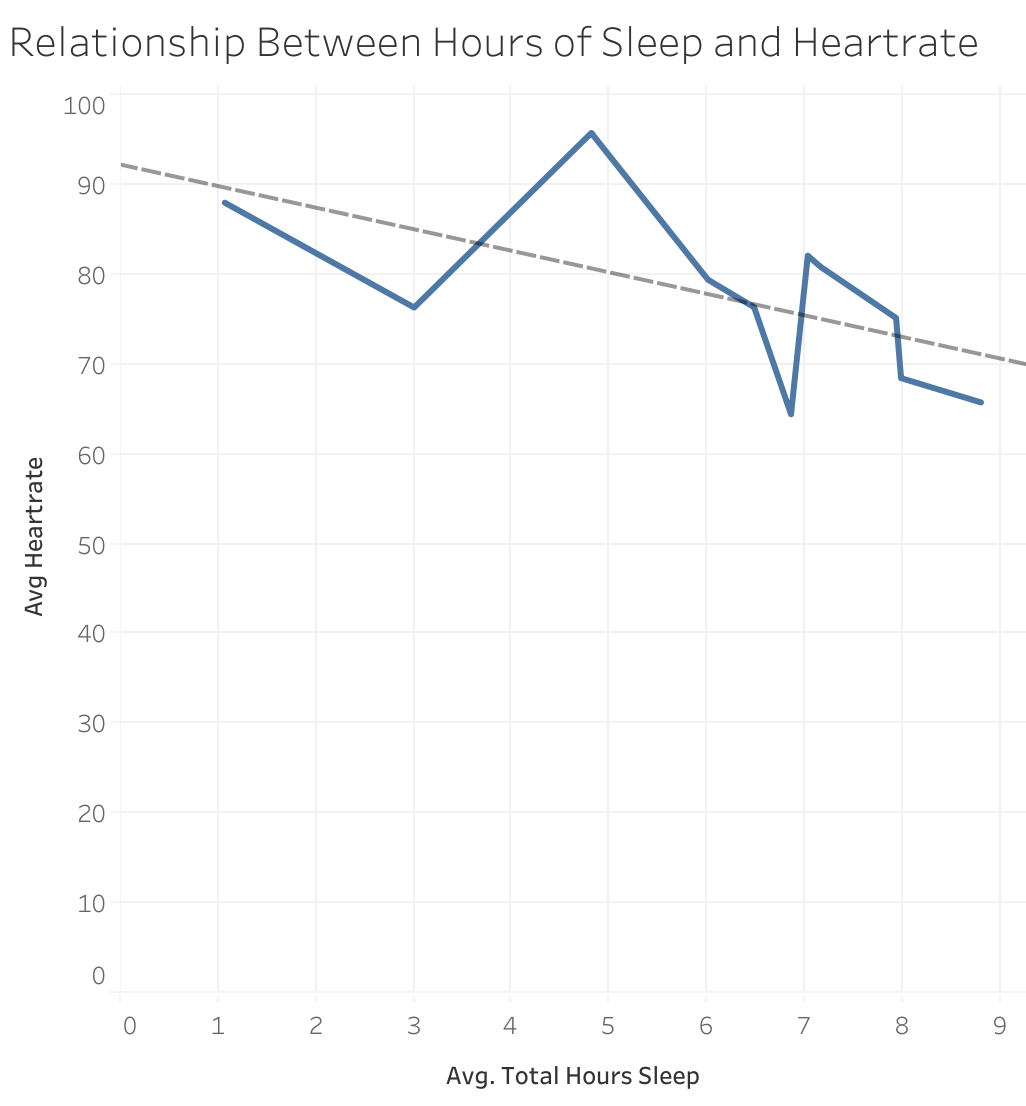
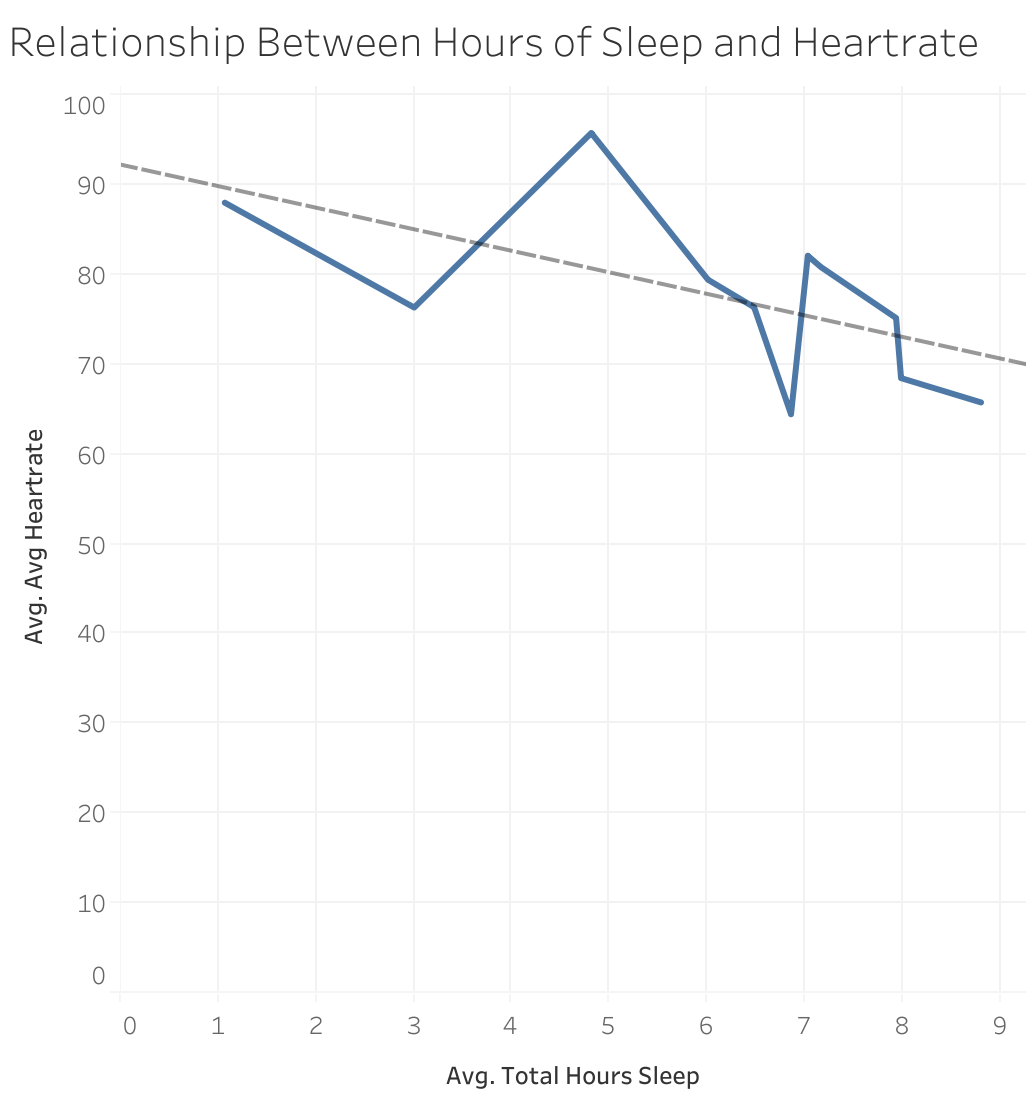

Results suggest that consumers with longer sleep durations tended to exhibit lower average heart rates, suggesting a potential relationship between sleep recovery and heart health. This insight supports Bellabeat’s focus on wellness tracking and suggests sleep-focused features could be valuable for health-conscious consumers. Further analysis suggested that the more a consumer weighed, the higher their average heartrate, however there was not enough consumer data to confirm this trend.

### Daily Activity Analysis

Next, analysis was conducted based upon daily activity comparing days of the week, at consumer level.

In [4]:
query = """

-- Create temporary table for day of week summary

WITH user_dow_summary AS (

    SELECT
      Id,

-- Extract weekday number from timestamp e.g. Monday = 1,Tuesday = 2 etc.

      FORMAT_TIMESTAMP("%w", parsed_activity_timestamp) AS dow_number,

-- Extract full weekday name
      FORMAT_TIMESTAMP("%A", parsed_activity_timestamp) AS day_of_week,

-- Categorise days into weekday or weekend
      CASE
        WHEN FORMAT_TIMESTAMP("%A", parsed_activity_timestamp)
          IN ("Sunday", "Saturday")
          THEN "Weekend"
        ELSE "Weekday"
      END AS part_of_week,

-- Calculate average daily steps
      AVG(SAFE_CAST(total_steps AS INT64)) AS average_steps

    FROM `white-berm-496207-v8.fitbit_data.daily_activity_merged`

-- Group by user and weekday
    GROUP BY 1, 2, 3, 4
)

-- Return summarised results
SELECT *
FROM user_dow_summary

-- Sort weekdays into correct calendar order
ORDER BY CAST(dow_number AS INT64);

"""

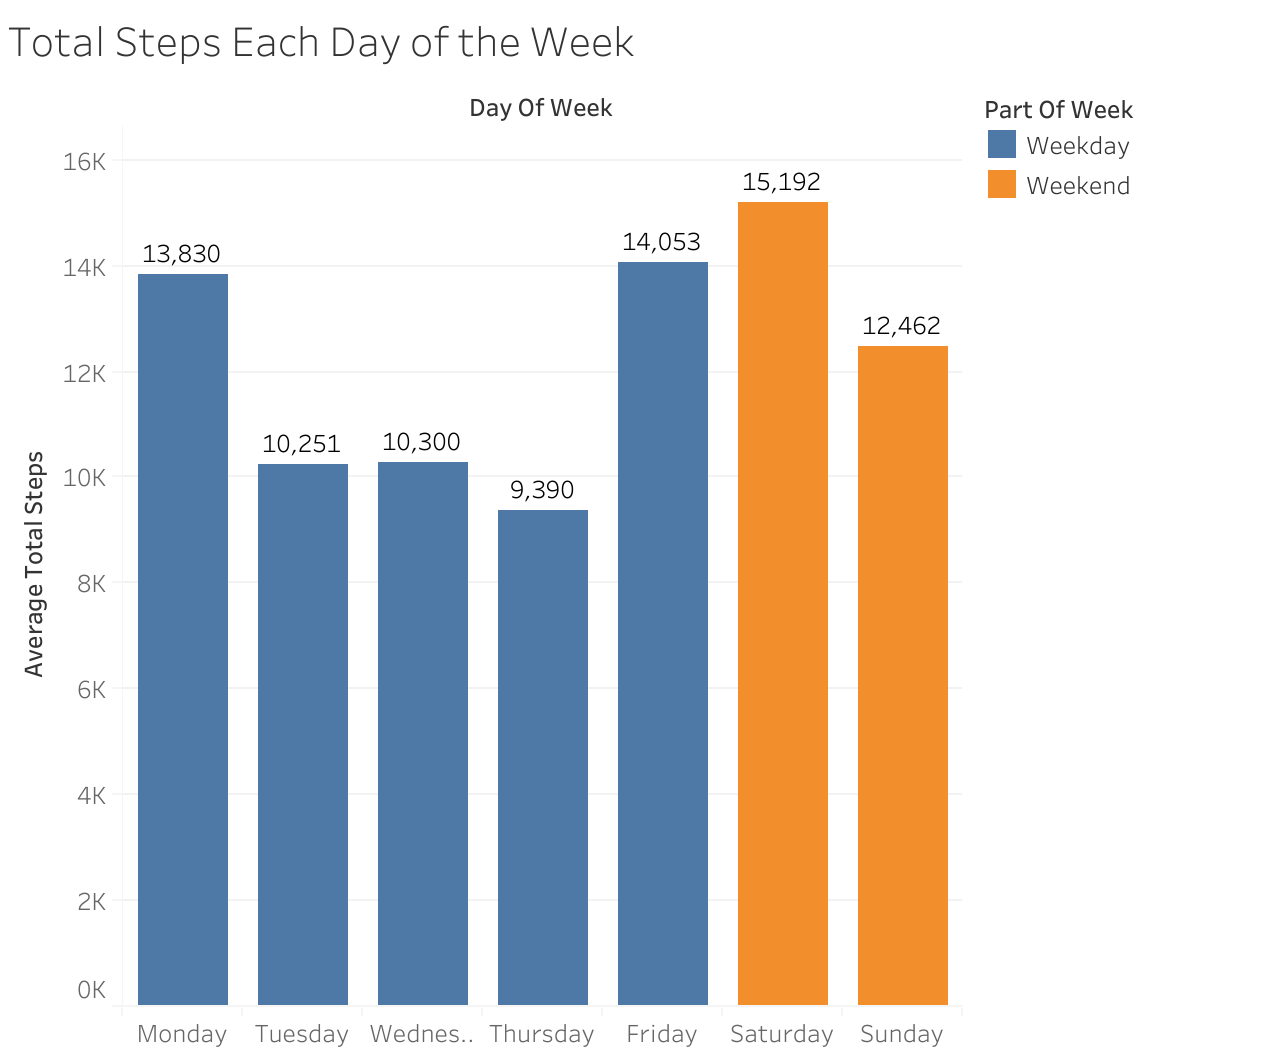
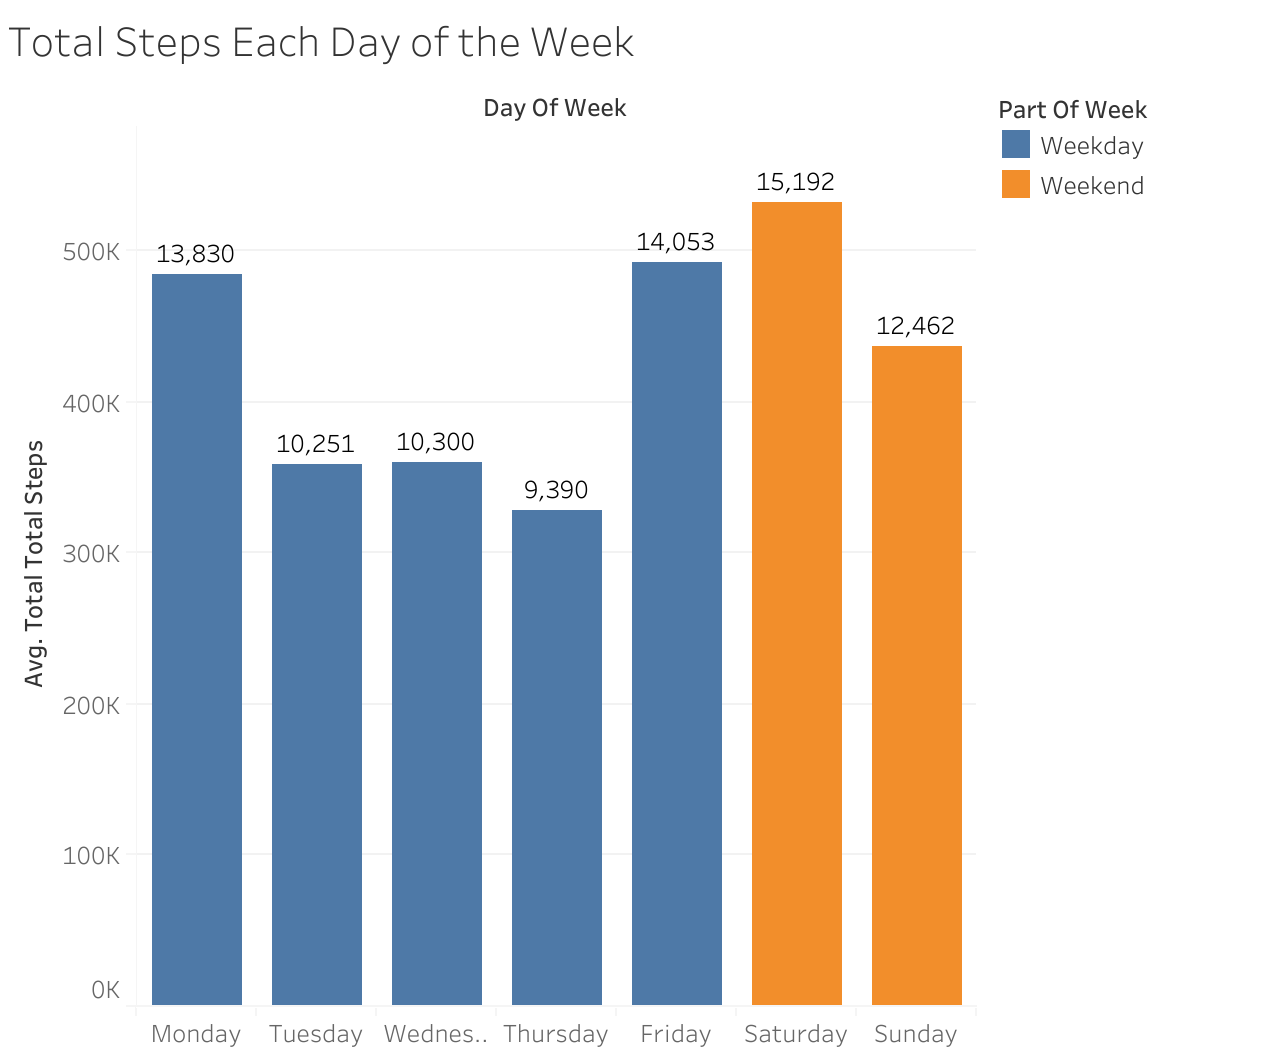

This analysis shows that consumers record the most steps on their FitBit on Friday and Saturday, closely followed by Monday. Suggesting that there is high engagement with step tracking on smart devices, particularly on weekends. 

# Recommendations

**Business Task**<br/>
Analyse smart device data to gain insight into how consumers are using their smart devices, then focus on one of Bellabeats products to identify potential growth opportunities for the business. 

Considering the business task and these findings, my recommendations are as follows:
1. **Improve sleep insights on the Bellabeat app** - Analysis suggests that consumers are consistently using their smart devices to track their sleep. As part of the Bellabeat membership, personalised guidance could be provided on the importance of getting enough sleep and the impact this has on their overall health and wellness. There may also be opportunities for Bellabeat to detect irregular sleep patterns and provide personalised insights on this too. Finally, the presence of naps suggest that some consumers have fragmented sleep and sleep recovery is not only at night, meaning consumers may benefit from nap tracking or “recovery recommendations” during the day, not just overnight sleep tracking.
2. **Promote step tracking as part of tracking activity** - Analysis suggests that consumers use their smart devices to track their steps on a daily basis. Currently, Bellabeat states that their products track activity, but specifically highlighting step tracking as a feature could increase the number of consumers.
3. **Focus on automated tracking features** - During the initial cleaning process, it was identified that only one consumer had used their device for calorie tracking. Furthermore, less than half of the surveyed consumers recorded their weight, suggesting lower engagement with these features which both require manual entry. Bellabeat should prioritise automated tracking features, such as sleep, heart rate, and activity (steps) monitoring, as these features demonstrated higher engagement levels than manually logged features like weight and calorie tracking.